## Examples: Hierachical clustering

#### In this notebook, we will cover hierarchical clustering, focusing on agglomerative clustering. We will explore the algorithm, interpret dendograms, implement it using sklearn and Scipy, and determine the optimal number of clusters

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Understand hierarchical clustering
#### - Interpret dendograms
#### - Implement agglomerative clustering in sklearn and SciPy
#### - Determine the optimal number of clusters from a dendogram
#### - Explore the advantages and disadvantages of agglomerative hierarchical clustering

In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Feature 2')

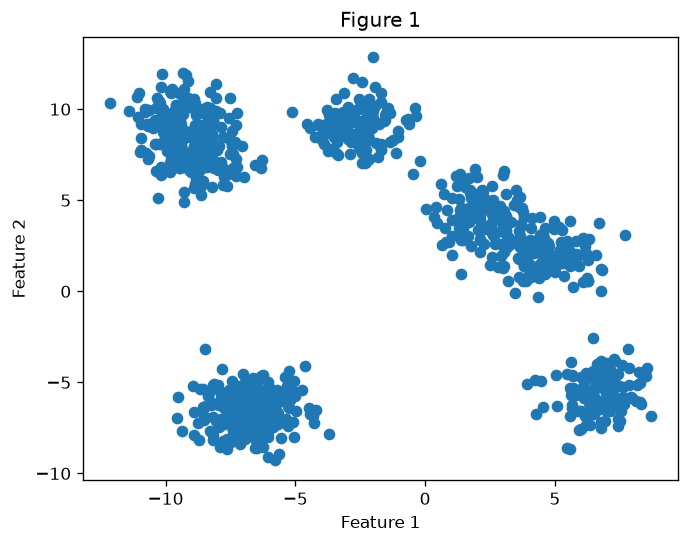

In [3]:
# make 8 blobs in 2D space
n_features = 2
centers = 8

X, y = make_blobs(
    n_samples=1000,
    centers=centers,
    n_features=n_features,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=[*[f'feature_{i}' for i in range(n_features)]]
)

plt.figure(dpi=120)

x1 = df['feature_0']
x2 = df['feature_1']
plt.scatter(x1, x2)

plt.title('Figure 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [4]:
df.head()

,feature_0,feature_1
0,-7.653416,-8.124764
1,-8.499175,-3.194161
2,-6.668610,-6.976823
3,0.619695,5.911028
4,-8.928063,8.763640


### Scaling of features

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

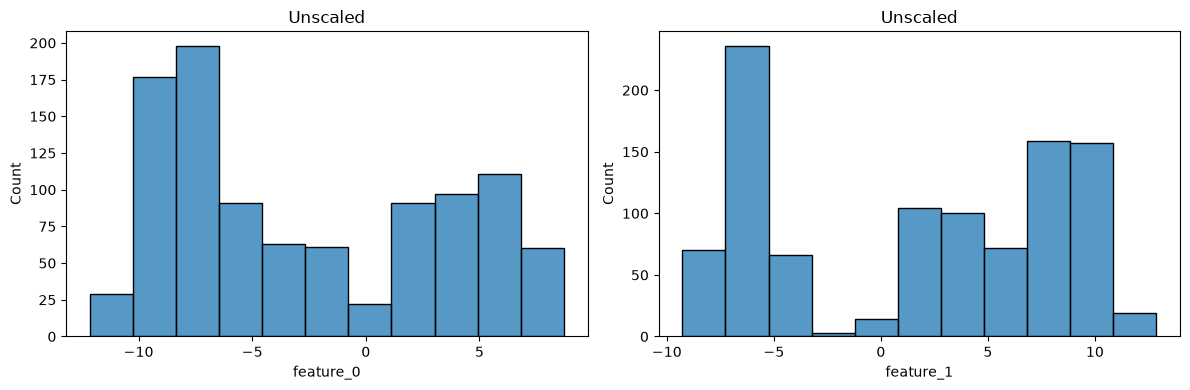

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
sns.histplot(df.iloc[:, 0])
plt.title('Unscaled')
plt.gca().set_aspect('auto', adjustable='box')

plt.subplot(1,2,2)
sns.histplot(df.iloc[:, 1])
plt.title('Unscaled')
plt.gca().set_aspect('auto', adjustable='box')

plt.tight_layout()
plt.show()

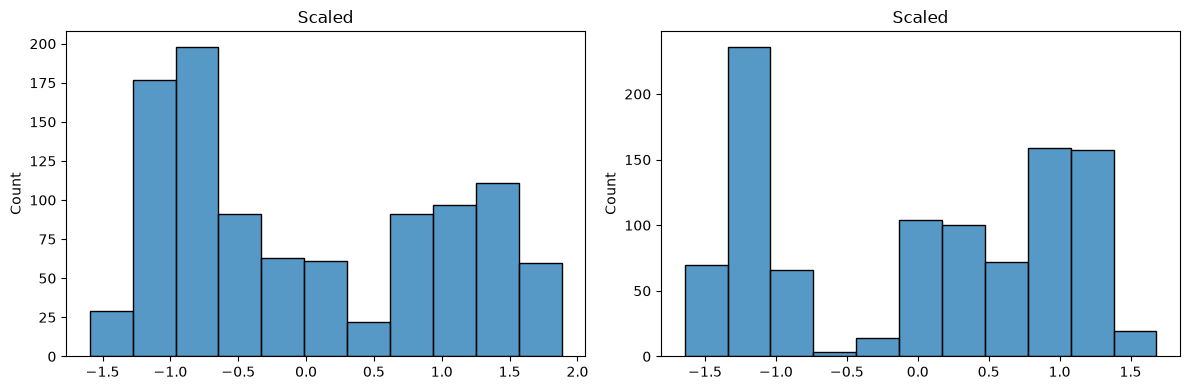

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
sns.histplot(X_scaled[:, 0])
plt.title('Scaled')
plt.gca().set_aspect('auto', adjustable='box')

plt.subplot(1,2,2)
sns.histplot(X_scaled[:, 1])
plt.title('Scaled')
plt.gca().set_aspect('auto', adjustable='box')

plt.tight_layout()
plt.show()

### Generate dendogram

In [9]:
from scipy.cluster.hierarchy import ward, dendrogram
import scipy.cluster.hierarchy as sch

In [10]:
help(sch.linkage)

Help on function linkage in module scipy.cluster.hierarchy._hierarchy_impl:

linkage(y, method='single', metric='euclidean', optimal_ordering=False)
    Perform hierarchical/agglomerative clustering.

    The input y may be either a 1-D condensed distance matrix
    or a 2-D array of observation vectors.

    If y is a 1-D condensed distance matrix,
    then y must be a :math:`\binom{n}{2}` sized
    vector, where n is the number of original observations paired
    in the distance matrix. The behavior of this function is very
    similar to the MATLAB linkage function.

    A :math:`(n-1)` by 4 matrix ``Z`` is returned. At the
    :math:`i`-th iteration, clusters with indices ``Z[i, 0]`` and
    ``Z[i, 1]`` are combined to form cluster :math:`n + i`. A
    cluster with an index less than :math:`n` corresponds to one of
    the :math:`n` original observations. The distance between
    clusters ``Z[i, 0]`` and ``Z[i, 1]`` is given by ``Z[i, 2]``. The
    fourth value ``Z[i, 3]`` represen

In [11]:
# perform hierarchical clustering
linkage_matrix = sch.linkage(
    X_scaled,
    method='average',
    metric='euclidean'
)

In [12]:
linkage_matrix

array([[2.20000000e+01, 6.39000000e+02, 5.33693149e-04, 2.00000000e+00],
       [2.94000000e+02, 6.63000000e+02, 1.16491356e-03, 2.00000000e+00],
       [2.24000000e+02, 3.83000000e+02, 1.72163084e-03, 2.00000000e+00],
       ...,
       [1.98900000e+03, 1.99300000e+03, 1.43501375e+00, 3.74000000e+02],
       [1.99000000e+03, 1.99600000e+03, 2.25622938e+00, 6.24000000e+02],
       [1.99500000e+03, 1.99700000e+03, 2.35979416e+00, 1.00000000e+03]],
      shape=(999, 4))

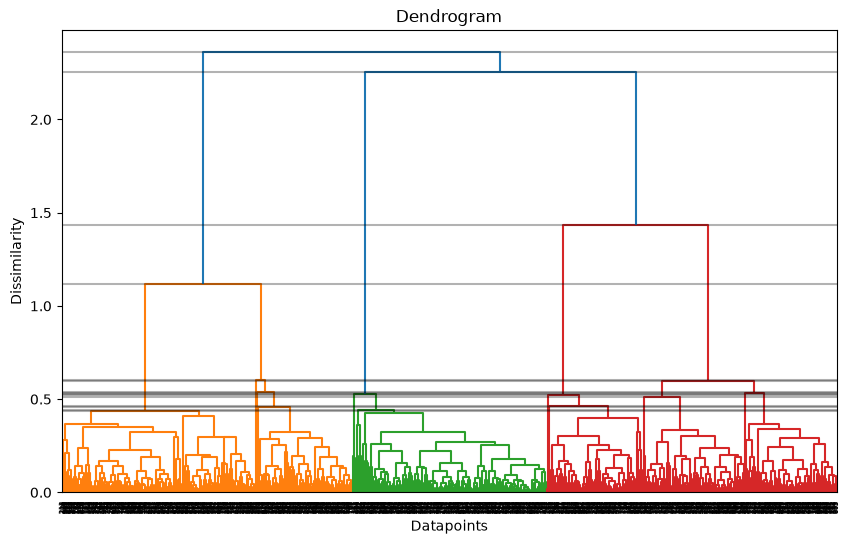

In [19]:
# Generate and plot dendrogram
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(linkage_matrix)

# The linkage matrix also contains the dissimilarity measures associated with each merge we've done
# We can use these to plot a few horizontal lines on the dendrogram that can help use find the
# right number of clusters better
z = linkage_matrix[:,2]

for i in range(1, 16):
    rng = [z[-i], z[-i]]
    dom = [0,40000]
    plt.plot(dom, rng, 'black', alpha=0.3)

plt.title('Dendrogram')
plt.xlabel('Datapoints')
plt.ylabel('Dissimilarity')

plt.show()

### Agglomerative hierarchical clustering in Sklearn

In [20]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
K = 4
hc = AgglomerativeClustering(
    n_clusters=k,
    linkage='average',
    metric='euclidean'
).fit(X_scaled)

df['cluster_label'] = hc.labels_
df['cluster_label'] = df['cluster_label'].astype('int64')

Text(0, 0.5, 'Feature 2')

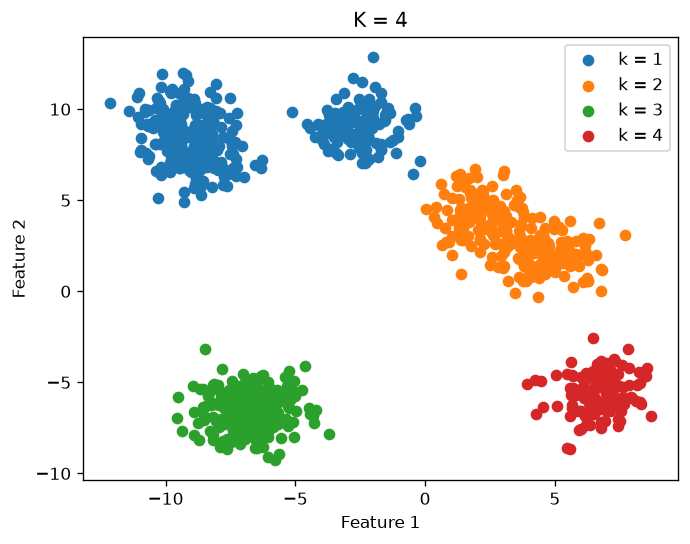

In [24]:
# plot data
plt.figure(dpi=120)
for k in range(K):
    x1 = df[df['cluster_label'] == k]['feature_0']
    x2 = df[df['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))

plt.legend()
plt.title("K = 4")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Cluster profiling

In [25]:
df.groupby('cluster_label').agg('median')

,feature_0,feature_1
cluster_label,,
0,-8.389787,8.737087
1,3.498841,2.932441
2,-6.672122,-6.564394
3,6.718905,-5.776086


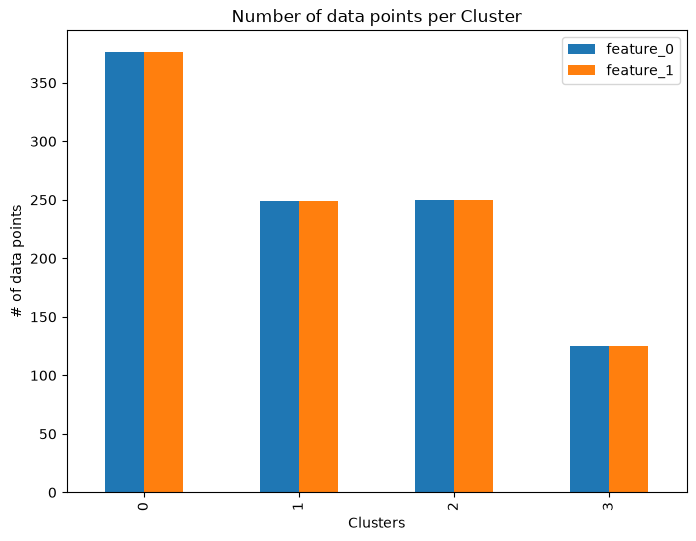

In [26]:
# we can also look at the size of each cluster by counting the data points it contains
df.groupby('cluster_label').count().reset_index().plot(
    kind='bar',
    x='cluster_label',
    figsize=(8,6),
    title='Number of data points per Cluster'
)

plt.xlabel("Clusters")
plt.ylabel("# of data points")
plt.show()